# Introduction: Titanic Exercise

At the start of the semester, the well-known Titanic exercise was introduced as an
introductory assignment to begin exploring the field of artificial intelligence and
data analysis. The purpose of this exercise is to gain hands-on experience with basic
AI-related workflows while becoming familiar with common data science tools.

This notebook explores the Titanic dataset using Python and widely used data analysis
libraries. The goal is to examine the data, identify patterns, and answer questions
related to passenger survival, providing a foundation for future work in machine
learning and artificial intelligence.


## Step 1 : Explore the data set

As I have a programming background, I made use of Visual Studio Code enviornment and the given python notebook to work on the given exercise. 

Various criteria must be met before this step can be seen as completed. 
How these criteria are met is given below.

### Criteria
- Load the dataset into a table (a DataFrame).
- Show the first rows and the column names.
- Identify missing values (which columns have gaps?).
- Answer the following questions
  - What percentage survived?
  - Did survival differ by ticket class?
  - Did survival differ by gender?
  - Does age seem to matter?
  - Does ticket price relate to survival?

The first two criteria are straight up and are done in 3 lines, as can be seen below.

In [71]:
import sklearn
import pandas
import seaborn

data = pandas.read_csv("phase0-titanic/titanic.csv")
data.sample(5)


,pnumber,pclass,survived,name,age,embarked,home.dest,room,ticket,boat,sex
752,753,3rd,0,"Danoff, Mr Yoto",27.0,Southampton,"Bulgaria Chicago, IL",NaN,NaN,NaN,male
502,503,2nd,1,"Mellor, Mr William John",19.0,Southampton,"Chelsea, London",NaN,NaN,B,male
130,131,1st,1,"Harper, Mrs Henry Sleeper (Myna Haxtun)",49.0,Cherbourg,"New York, NY",NaN,NaN,3,female
585,586,2nd,1,"Wells, Master Ralph Lester",2.0,Southampton,"Cornwall / Akron, OH",NaN,NaN,NaN,male
504,505,2nd,0,"Milling, Mr Jacob Christian",48.0,Southampton,"Copenhagen, Denmark",NaN,NaN,-271,male


For the third criteria, a single line gives us the missing values.
As the line returns, there should be 1313 entries per colomn. It can be seen that many values are mossing

In [72]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 1313 entries, 0 to 1312
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pnumber    1313 non-null   int64  
 1   pclass     1313 non-null   str    
 2   survived   1313 non-null   int64  
 3   name       1313 non-null   str    
 4   age        633 non-null    float64
 5   embarked   821 non-null    str    
 6   home.dest  754 non-null    str    
 7   room       77 non-null     str    
 8   ticket     69 non-null     str    
 9   boat       347 non-null    str    
 10  sex        1313 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 113.0 KB


Now when it comes to the last criteria, various questions must be answered.

In order to answer most of the questions, its important to know the amount that survived. It gives us a baseline.

In [73]:
data["survived"].value_counts()


survived
0    864
1    449
Name: count, dtype: int64

While this gives the fastest overview, with the least amount of lines, there is quicker way when it comes to giving the return value in percentages.

In [74]:
nu_survived = (data["survived"] == 1).sum()
pr_survived = (data["survived"].mean() * 100).round(2)

print(f"Total survived : {nu_survived}")
print(f"Percentage survived : {pr_survived}%")


Total survived : 449
Percentage survived : 34.2%


Now that it is established which amount has survived, there can be looked into if there are great differences between the survival rate of sub groups.

In [75]:
grouped = data.groupby("pclass")["survived"]

for pclass, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()
    percentage_survived = round(group.mean() * 100, 2)

    print(f"Class {pclass}:")
    print(f"  Total in class : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")


Class 1st:
  Total in class : 322
  Total survived : 193
  Percentage survived : 59.94%

Class 2nd:
  Total in class : 280
  Total survived : 119
  Percentage survived : 42.5%

Class 3rd:
  Total in class : 711
  Total survived : 137
  Percentage survived : 19.27%



In [76]:
grouped = data.groupby("sex")["survived"]

for sex, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()
    percentage_survived = round(group.mean() * 100, 2)

    print(f"Class {sex}:")
    print(f"  Total passengers : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")


Class female:
  Total passengers : 463
  Total survived : 307
  Percentage survived : 66.31%

Class male:
  Total passengers : 850
  Total survived : 142
  Percentage survived : 16.71%



Now when it comes to age, it would be the best to create our own subgroups, rather than per specific age. 
Generally speaking, we can group people in children (0-17), young adult(18-35), adult(36-60), and eldery(61+). 
These subgroups give us an clear enough indication on how someones life phase influences the survival rate.

It is good to mention, as only about half of the passengers had their age listed. So while the results can give you a general idea, it is not something reliable due to the massive chunk of missing data.

In [77]:
bins = [0, 17, 35, 60, 120]
labels = ["Children", "Young Adult", "Adult", "Elderly"]

age_grouped = data.groupby(pandas.cut(data["age"], bins=bins, labels=labels))[
    "survived"
]

for age_group, group in age_grouped:
    total_passengers = group.count()
    total_survived = group.sum()
    percentage_survived = round(group.mean() * 100, 2)

    print(f"{age_group}:")
    print(f"  Total in group : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")


Children:
  Total in group : 82
  Total survived : 53
  Percentage survived : 64.63%

Young Adult:
  Total in group : 327
  Total survived : 127
  Percentage survived : 38.84%

Adult:
  Total in group : 203
  Total survived : 97
  Percentage survived : 47.78%

Elderly:
  Total in group : 21
  Total survived : 4
  Percentage survived : 19.05%



Now the question is, can we draw conclusions based upon this? 
While if we just look at the data, we can defintely say yes. 
Yet, it is not as straight forward. We do not know any of the circumstances. 
Passenger data alone makes it difficult to draw conclusions, if there was more given data on the scenario, we might could.

## Step 2 : Building a first model

For the second step, we will take a first dive into how we can create a model and how we can use it.

For this step various criteria must be met in order to be seen as completed.

### Criteria

- Select a few features (for example: Pclass, Sex, Age, Fare, Embarked).
- Handle missing values in a simple way (for example: fill missing ages with the median).
- Train a model (for example: logistic regression, decision tree, or random forest).
- Evaluate the model using a simple metric (accuracy is fine).
- Compare your model to a “stupid baseline” (for example: predicting that nobody survives, or that everyone survives).

To create a model, a new dataframe is created based upon the initial dataframe. 
Some columns will me used and others neglected.
Besides that, as we found out early on, there are many missing values. 
These missing values will be adressed by either using the average or the most common value, depending to which category it belongs.
Next to this, as most ML algorithms are not directly work with strings or text, catogeries which do make use of these are mapped to numerical values.


**sex**
| Original | Numeric |
| -------- | ------- |
| female   | 0       |
| male     | 1       |

**pclass** 
| Original | Numeric |
| -------- | ------- |
| 1st      | 1       |
| 2nd      | 2       |
| 3rd      | 3       |

In [78]:
features = ["pclass", "sex", "age", "embarked"]
x = data[features]
y = data["survived"]

x["age"] = x["age"].fillna(x["age"].median())
x["embarked"] = x["embarked"].fillna(x["embarked"].mode()[0])

x["pclass"] = x["pclass"].map({"1st": 1, "2nd": 2, "3rd": 3}).astype(int)
x["sex"] = x["sex"].map({"male": 0, "female": 1}).astype(int)

x = pandas.get_dummies(x, columns=["embarked"], drop_first=False)
x = pandas.get_dummies(x, columns=["pclass"], drop_first=False)

x.sample(5)


,sex,age,embarked_Cherbourg,embarked_Queenstown,embarked_Southampton,pclass_1,pclass_2,pclass_3
77,0,30.0,False,False,True,True,False,False
1149,1,30.0,False,False,True,False,False,True
914,1,30.0,False,False,True,False,False,True
311,1,30.0,True,False,False,True,False,False
1217,0,30.0,False,False,True,False,False,True


In [79]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest: {accuracy_rf:.2f}")


Random Forest: 0.79


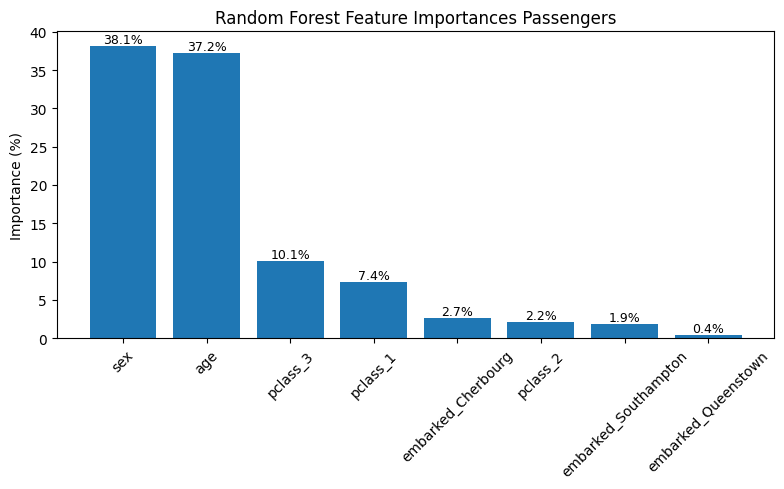

In [80]:
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.feature_importances_
feature_names = x.columns

importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(range(len(importances_pct)), feature_names[indices], rotation=45)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances Passengers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [81]:
from sklearn.metrics import classification_report

target_names = ["no", "yes"]
print("Train set:")
predictions = rf_model.predict(X_train)
report = classification_report(y_train, predictions, target_names=target_names)
print(report)

print("Test set:")
predictions = rf_model.predict(X_test)
report = classification_report(y_test, predictions, target_names=target_names)
print(report)


Train set:
              precision    recall  f1-score   support

          no       0.87      0.96      0.91       696
         yes       0.90      0.71      0.79       354

    accuracy                           0.88      1050
   macro avg       0.88      0.83      0.85      1050
weighted avg       0.88      0.88      0.87      1050

Test set:
              precision    recall  f1-score   support

          no       0.80      0.90      0.85       168
         yes       0.78      0.60      0.68        95

    accuracy                           0.79       263
   macro avg       0.79      0.75      0.76       263
weighted avg       0.79      0.79      0.79       263



Personally, I am interested if there are differences in accuracies between various machine learnings.
Therefor I decided to compare it to two other ways. 
Some considered stronger than the other, therefor i will cross validate them, to more reliable accuracy and reduce randomness

### Different models

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# XGboost
xgb_model = XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Model Accuracy Comparison (80/20 Split):")
print(f"Random Forest: {accuracy_rf:.2f}")
print(f"KNN: {accuracy_knn:.2f}")
print(f"XGBoost: {accuracy_xgb:.2f}")
print(f"Logistic Regression: {accuracy_lr:.2f}")


Model Accuracy Comparison (80/20 Split):
Random Forest: 0.79
KNN: 0.77
XGBoost: 0.81
Logistic Regression: 0.81


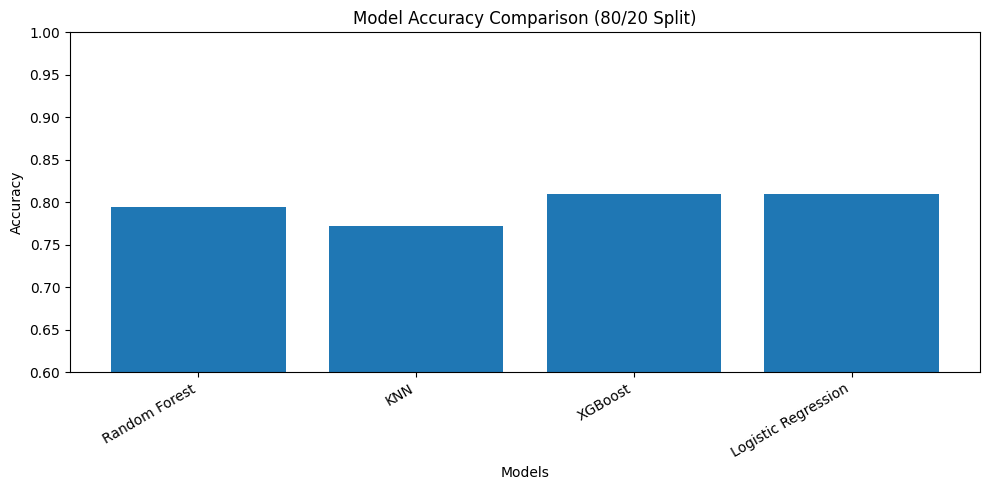

In [84]:
import matplotlib.pyplot as plt

models = ["Random Forest", "KNN", "XGBoost", "Logistic Regression"]
accuracies = [accuracy_rf, accuracy_knn, accuracy_xgb, accuracy_lr]

plt.figure(figsize=(10, 5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (80/20 Split)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()


Now what I noticed is that this only includes the passenger. The titanic also has over 900 crew members. Considering this, I was curious whether this would make a difference and if so, how. Therefor, I decided on creating a seperate file for this. 